In [14]:
from pathlib import Path
from datetime import datetime
import json
from io import BytesIO
from zipfile import ZipFile, BadZipFile
from tqdm import tqdm
import requests
import time

import pandas_datareader.data as web
import yfinance as yf
import pandas as pd
from yahoofinancials import YahooFinancials

from pprint import pprint

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import warnings

In [15]:
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [16]:
DATA_STORAGE = "E:/mlft/data"
data_path = 'sec-filings/fsn'
data_path = DATA_STORAGE/Path(data_path)
data_path

WindowsPath('E:/mlft/data/sec-filings/fsn')

## Metadata json

In [17]:
# file = data_path / '2023_11' / 'source' / 'notes-metadata.json'
# with file.open() as f:
#     data = json.load(f)

# pprint(data)

## Data Organization

FSN 파일 구성

| File | Dataset      | Description                                                 |
|------|--------------|-------------------------------------------------------------|
| SUB  | Submission   | Identifies each XBRL submission by company, form, date, etc |
| TAG  | Tag          | Defines and explains each taxonomy tag                      |
| DIM  | Dimension    | Adds detail to numeric and plain text data                  |
| NUM  | Numeric      | One row for each distinct data point in filing              |
| TXT  | Plain Text   | Contains all non-numeric XBRL fields                        |
| REN  | Rendering    | Information for rendering on SEC website                    |
| PRE  | Presentation | Detail on tag and number presentation in primary statements |
| CAL  | Calculation  | Shows arithmetic relationships among tags                   |

## Submission Data

In [18]:
sub = pd.read_parquet(data_path / '2023_11' / 'parquet' / 'sub.parquet')
# sub.info()

### Get Stock submission

- submission 데이터 세트에는 파일을 검색하는 데 필요한 고유 식별자(CIK(Central Index Key)와 등록 번호(Adsh)가 포함되어 있다.

| 항목        | 설명                                               |
|------------|----------------------------------------------------|
| name       | 기업 또는 단체의 이름                   |
| adsh       | Submission Identifier로, 특정 보고서의 고유 식별자 |
| cik        | Central Index Key로, 기업의 고유한 식별 번호    |
| sic        | Standard Industrial Classification으로, 기업의 산업 분류 코드|
| countryba  | Business Address Country로, 기업의 사업장 주소 국가|
| stprba     | Business Address State/Province로, 기업의 사업장 주소 주 또는 지방|
| cityba     | Business Address City로, 기업의 사업장 주소 도시|
| zipba      | Business Address ZIP Code로, 기업의 사업장 주소 우편번호|
| bas1       | Business Address Street Address1로, 기업의 사업장 주소의 상세한 거리 주소|
| form       | 제출된 문서의 양식(보고서 유형)           |
| period     | 보고서의 기간                         |
| fy         | Fiscal Year로, 보고서가 참조하는 재무연도 |
| fp         | Fiscal Period로, 보고서가 참조하는 재무기간|
| fye        | Fiscal Year End로, 재무연도의 종료. "FYE December 31"는 재무연도가 12월 31일에 끝나는 것을 의미 |
| filed      | 보고서가 제출된 날짜                     |


In [19]:
# name = 'AMAZON COM INC'

In [20]:
# stock = sub[sub.name == name].T.dropna().squeeze()
# key_cols = ['name', 'adsh', 'cik', 'name', 'sic', 'countryba', 'stprba',
#             'cityba', 'zipba', 'bas1', 'form', 'period', 'fye', 'filed']
# stock = stock.loc[key_cols].iloc[:,0]

## Build fundamentals dataset

- Central index key를 사용하면 Stock에서 사용할 수 있는 모든 과거 분기별 파일을 식별할 수 있으며 이 정보를 결합하여 26개의 Form 10-Q와 9개의 연간 Form 10-K를 얻을 수 있다.

https://www.sec.gov/edgar/searchedgar/companysearch

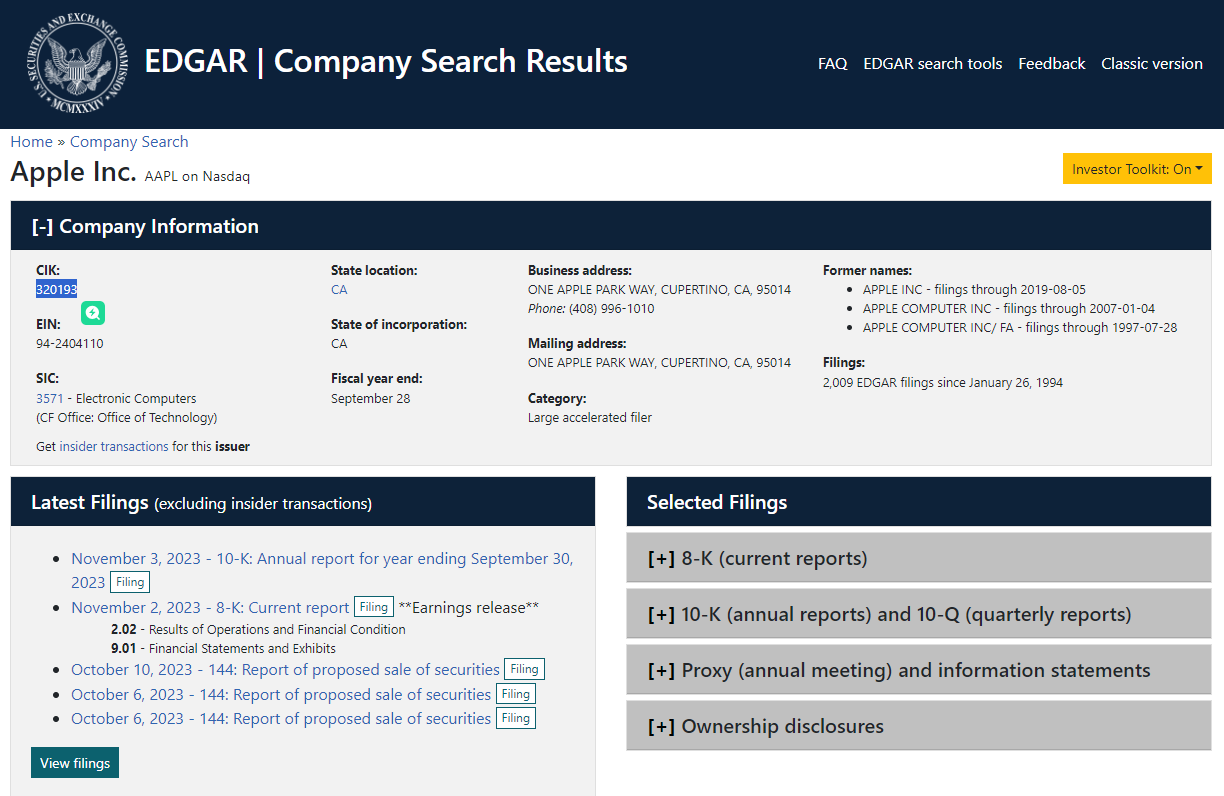

In [21]:
stock_cik = 1045810 #search in edgar
ticker="nvda" #download from yahoo

---

In [22]:
ticker = ticker.upper()

In [23]:
splits = {"20000627":2,
          "20010912":2,
         "20060407":2,
         "20070911":1.5,
         "20210720":4}

In [24]:
stock_subs = pd.DataFrame()
for sub in data_path.glob('**/sub.parquet'):
    sub = pd.read_parquet(sub)
    stock_sub = sub[(sub.cik.astype(int) == stock_cik) & (sub.form.isin(['10-Q', '10-K']))]
    stock_subs = pd.concat([stock_subs, stock_sub])

In [25]:
stock_subs.form.value_counts()

form
10-Q    44
10-K    14
Name: count, dtype: int64

### Get numerical filing data

각 파일에 대한 등록 번호를 사용하여 NUM 및 TXT 파일에서 적절한 XBRL 태그(listed in the TAG file)를 선택하여 관심 있는 숫자 또는 textual/footnote 데이터 지점을 얻을 수 있다

먼저 19개의 Apple 파일에서 사용 가능한 모든 수치 데이터를 추출한다.

In [26]:
stock_nums = pd.DataFrame()

# data_path 내의 모든 하위 디렉토리에 있는 'num.parquet' 파일들에 대한 루프를 돈다.
for num in data_path.glob('**/num.parquet'):
    # 'num.parquet' 파일을 읽고 'dimh' 열을 삭제.
    num = pd.read_parquet(num).drop('dimh', axis=1)
    # 'aapl_subs' DataFrame의 'adsh' 열에 있는 값들을 가지고 있는 행만 선택.
    stock_num = num[num.adsh.isin(stock_subs.adsh)]
    # print(len(aapl_num))
    stock_nums = pd.concat([stock_nums, stock_num])
stock_nums.ddate = pd.to_datetime(stock_nums.ddate, format='%Y%m%d')   
stock_nums.to_parquet(data_path / 'stock_nums.parquet')

In [27]:
# stock_nums.info()

## Create P/E Ratio from EPS and stock price data

시장 데이터와 결합하여 주가수익(P/E) 평가 비율을 계산할 수 있는 EPS(Endings per Devated Share)와 같은 유용한 분야를 선택할 수 있다.

### EPS

In [28]:
splits = splits

애플이 2014년 6월 4일에 주식을 7:1로 분할하고 다음 코드 블록에서 볼 수 있듯이 분할 전에 주당 조정 수익을 조정했다는 점을 고려할 필요가 있다:

In [29]:
# Filter by tag; keep only values measuring 1 quarter
eps = stock_nums[(stock_nums.tag == 'EarningsPerShareDiluted')
                & (stock_nums.qtrs == 1)].drop('tag', axis=1)

# Keep only most recent data point from each filing
eps = eps.groupby('adsh').apply(lambda x: x.nlargest(n=1, columns=['ddate']))

# Adjust earnings prior to stock split downward
for date, split in splits.items():
    date = pd.to_datetime(date)
    print(f"date: {date}, split: {split}")
    eps.loc[eps.ddate < date,'value'] = eps.loc[eps.ddate < date, 'value'].div(split)

eps = eps[['ddate', 'value']].set_index('ddate').squeeze().sort_index()
eps = eps.rolling(4,min_periods=4).sum().dropna()

date: 2000-06-27 00:00:00, split: 2
date: 2001-09-12 00:00:00, split: 2
date: 2006-04-07 00:00:00, split: 2
date: 2007-09-11 00:00:00, split: 1.5
date: 2021-07-20 00:00:00, split: 4


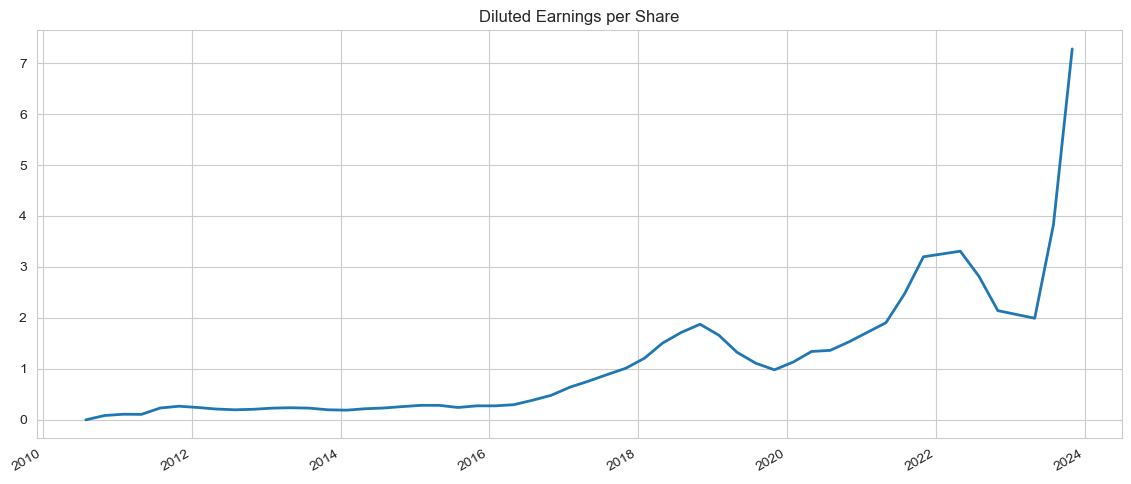

In [30]:
eps.plot(lw=2, figsize=(14, 6), title='Diluted Earnings per Share')
plt.xlabel('')
plt.savefig(f'diluted eps', dpi=300);

### PE Ratio

In [31]:
start_date = eps.index.min().date().strftime("%Y-%m-%d")
end_date = eps.index.max().date().strftime("%Y-%m-%d")
yahoo_financials = YahooFinancials(ticker)

In [32]:
prices = pd.DataFrame(yahoo_financials.get_historical_price_data(start_date,end_date,'daily').get(ticker).get("prices")).drop(['date','high','low','open','close','volume'], axis=1).rename(columns={"formatted_date":"date", "adjclose":"value"}).set_index("date")
prices.index = pd.to_datetime(prices.index)
stock = prices.resample('D').last().loc[start_date:end_date]
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4838 entries, 2010-08-02 to 2023-10-30
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   3335 non-null   float64
dtypes: float64(1)
memory usage: 75.6 KB


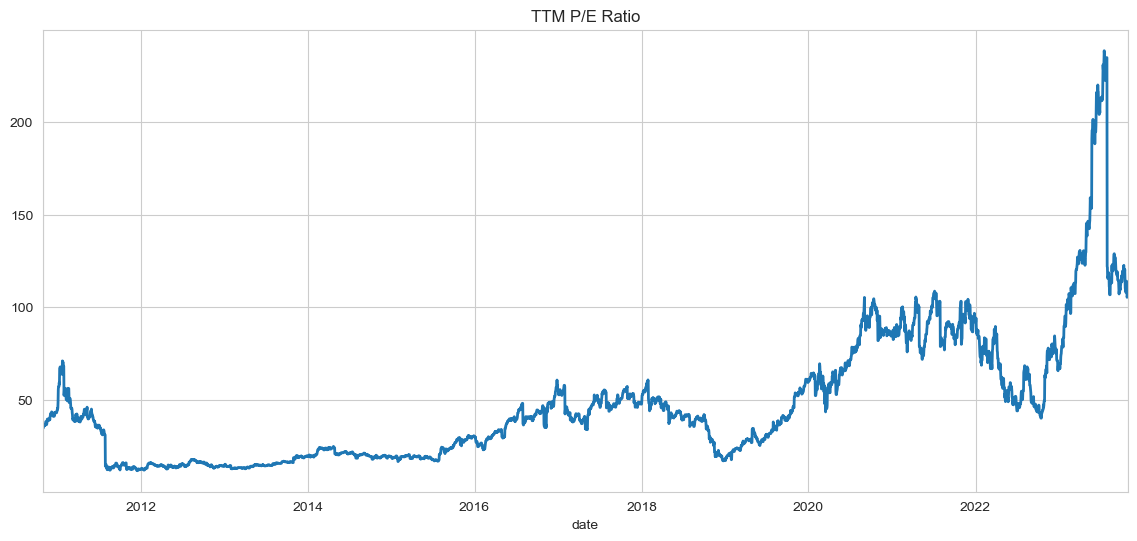

In [33]:
pe = stock.value.to_frame('price').join(eps.to_frame('eps'))
pe = pe.fillna(method='ffill').dropna()
pe['P/E Ratio'] = pe.price.div(pe.eps)
pe['P/E Ratio'].plot(lw=2, figsize=(14, 6), title='TTM P/E Ratio');

In [34]:
# pe.info()

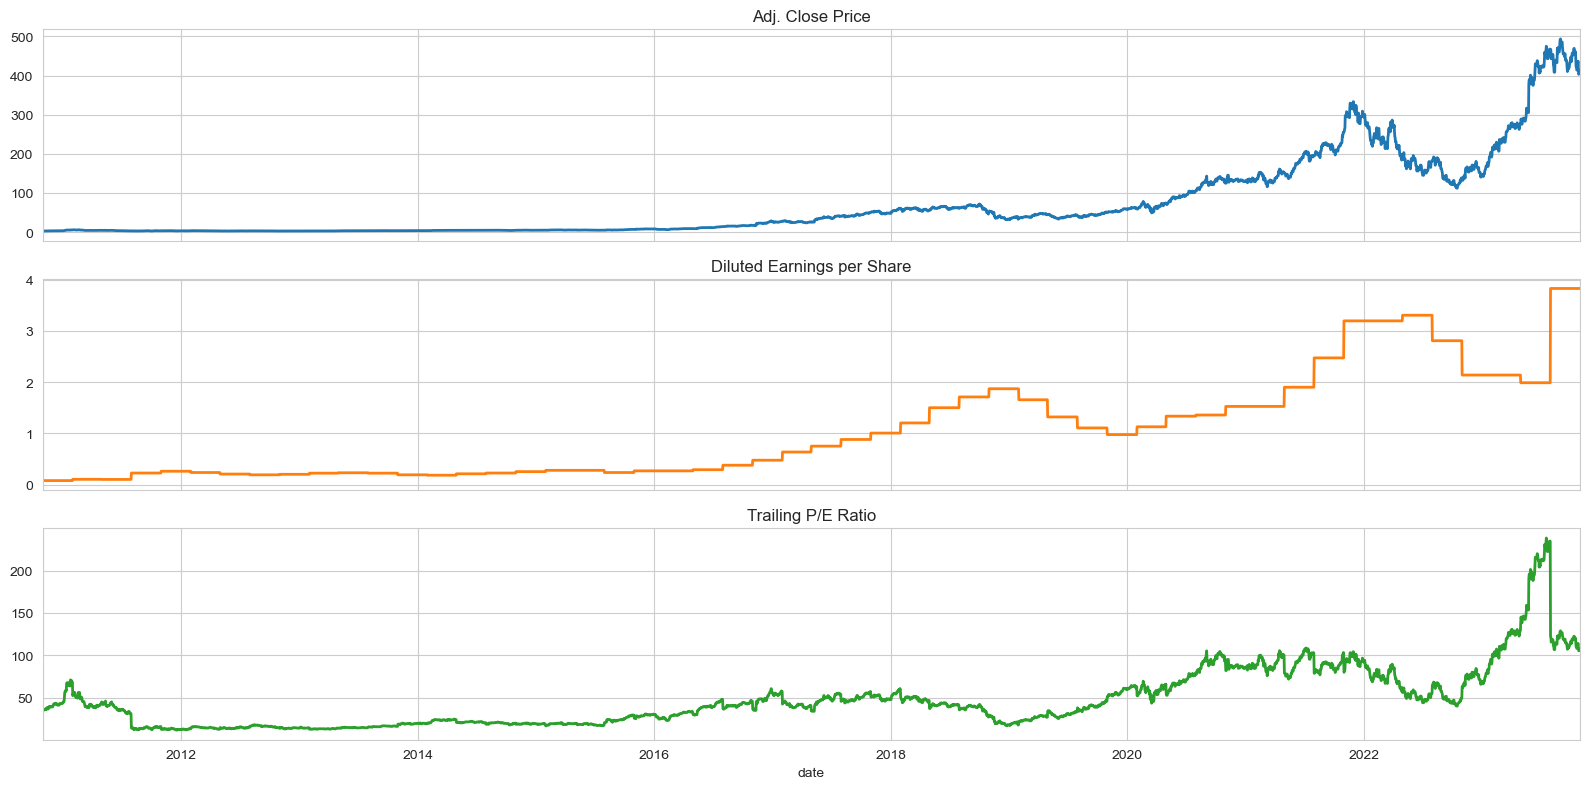

In [35]:
axes = pe.plot(subplots=True, figsize=(16,8), legend=False, lw=2)
axes[0].set_title('Adj. Close Price')
axes[1].set_title('Diluted Earnings per Share')
axes[2].set_title('Trailing P/E Ratio')
plt.tight_layout();

## Explore Additional Fields

The field tag references values defined in the taxonomy:

In [36]:
# stock_nums.tag.value_counts()

### Dividends

### Dividends Yield

In [37]:
dividends = pd.DataFrame(yahoo_financials.get_historical_price_data(start_date,end_date,'daily').get(ticker).get("eventsData").get("dividends")).T.drop('date', axis=1).rename(columns={"formatted_date":"date","amount":"value"}).set_index("date")
dividends.index = pd.to_datetime(dividends.index)
dividends = dividends.resample("Q").sum()

prices = prices.resample("Q").mean()

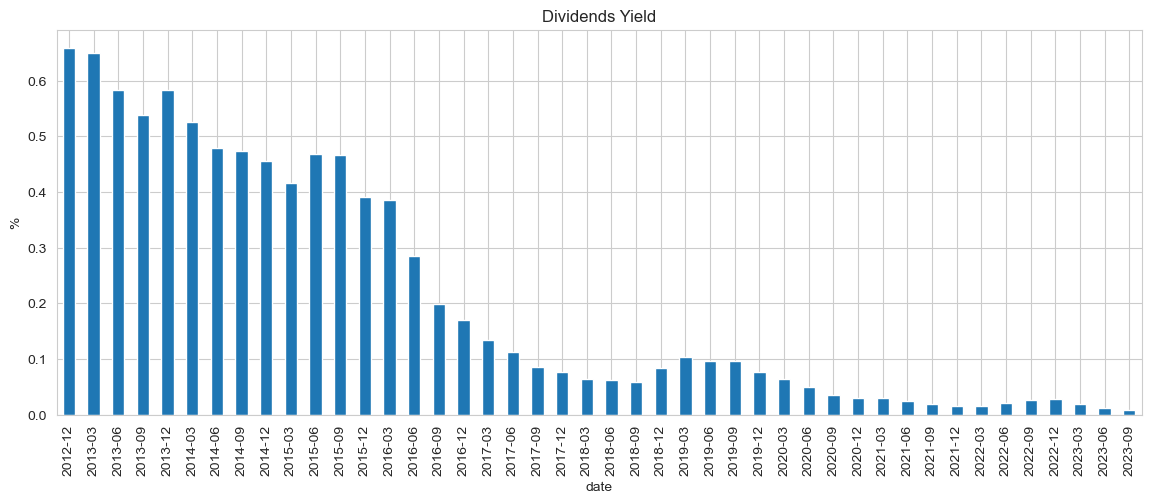

In [38]:
df = dividends.div(prices).dropna()*100
df.index = pd.to_datetime(df.index)
ax = df.plot.bar(figsize=(14, 5), title='Dividends Yield', legend=False)
ax.xaxis.set_major_formatter(mticker.FixedFormatter(df.index.strftime('%Y-%m')))
ax.set_ylabel("%");

### Dividends Payout ratio

In [40]:
df = dividends.div(pd.DataFrame(eps, columns=['value'])).dropna()*100
ax = df.plot.bar(figsize=(14, 5), title='Dividends Payout ratio', legend=False)
ax.xaxis.set_major_formatter(mticker.FixedFormatter(df.index.strftime('%Y-%m')))
ax.set_ylabel("%");

TypeError: no numeric data to plot

## Bonus: Textual Information

AAPL의 adshs는 txt 파일에는 없지만 이 financial statements에서 notes를 얻을 수 있습니다:

In [ ]:
txt = pd.read_parquet(data_path / '2016_2q' / 'parquet' /  'txt.parquet')

In [ ]:
txt.head()

---